In [1]:
import pandas as pd

In [ ]:
##step1->read the dataset 

df=pd.read_csv("predicted_index_data.csv")
df.head()

,Year,Month,Interest Rate,Unemployment Rate,Predicted Index Price
0,2016,6,2.53,3.80,984.27
1,2013,2,1.59,4.76,1005.45
2,2022,12,9.54,3.41,966.42
3,2024,5,9.69,5.93,938.15
4,2020,1,8.28,6.50,955.40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   25 non-null     int64  
 1   Month                  25 non-null     int64  
 2   Interest Rate          25 non-null     float64
 3   Unemployment Rate      25 non-null     float64
 4   Predicted Index Price  25 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 1.1 KB


In [ ]:
## drop unnecessary column 
df.drop(columns=["Month","Year"],axis=1,inplace=True)


In [5]:
df.head()

,Interest Rate,Unemployment Rate,Predicted Index Price
0,2.53,3.80,984.27
1,1.59,4.76,1005.45
2,9.54,3.41,966.42
3,9.69,5.93,938.15
4,8.28,6.50,955.40


In [6]:
## check null values 

df.isnull().sum()

Interest Rate            0
Unemployment Rate        0
Predicted Index Price    0
dtype: int64

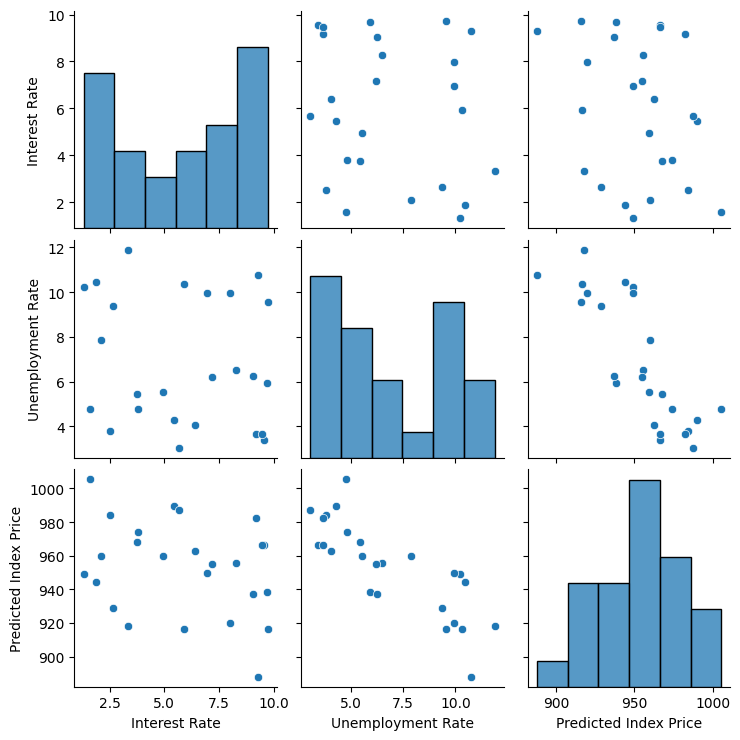

In [7]:
## do some visulization 
import seaborn as sns 
sns.pairplot(df)

In [8]:
## visualize correaltion 

df.corr()

,Interest Rate,Unemployment Rate,Predicted Index Price
Interest Rate,1.000000,-0.169757,-0.293304
Unemployment Rate,-0.169757,1.000000,-0.814886
Predicted Index Price,-0.293304,-0.814886,1.000000


Text(0.5, 1.0, 'showing relationship between interest rate and unemployment rate')

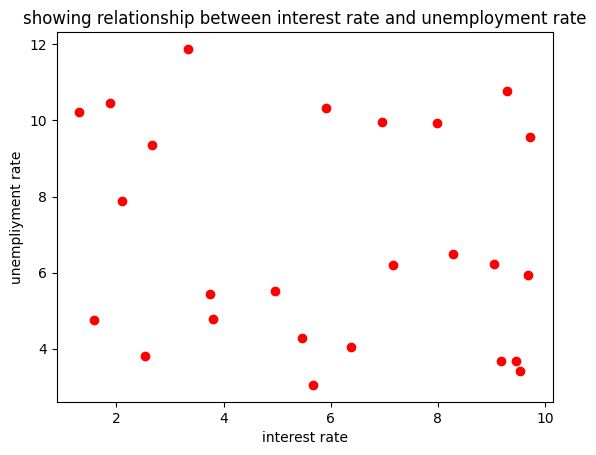

In [11]:
## visulaize the datapoints 
import matplotlib.pyplot as plt 
plt.scatter(x=df["Interest Rate"],y=df["Unemployment Rate"],color="red")
plt.xlabel("interest rate")
plt.ylabel("unempliyment rate")
plt.title("showing relationship between interest rate and unemployment rate")

In [ ]:
## divide the data set into X AND Y
X=df.drop(columns=["Predicted Index Price"],axis=1)
Y=df["Predicted Index Price"]



0      984.27
1     1005.45
2      966.42
3      938.15
4      955.40
5      967.92
6      944.35
7      955.07
8      959.52
9      959.94
10     989.73
11     949.21
12     982.35
13     917.93
14     949.42
15     973.85
16     987.11
17     916.39
18     928.91
19     916.17
20     919.74
21     966.19
22     937.11
23     962.75
24     887.91
Name: Predicted Index Price, dtype: float64

In [ ]:
## divise the data into training and test 
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)


1     1005.45
22     937.11
5      967.92
2      966.42
12     982.35
Name: Predicted Index Price, dtype: float64

In [18]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.fit_transform(X_test)


In [19]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)

LinearRegression()

In [21]:
## do prediction 
y_pred=regression.predict(X_test)
y_pred

array([950.09061085, 964.40414259, 980.87255537, 951.68698059,
       939.25230889, 951.97306555, 911.92644727])

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
print(mse)
print(mae)

133.86752442624658
10.074841269841338


In [23]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,y_pred)
score

0.7088040751764166

In [24]:
## adjusted r-squared 
adjusted_r2_squared=1-(((1-score)*(len(df))-1)/(len(df)-X_test.shape[1]-1))
adjusted_r2_squared

0.7145500854277462

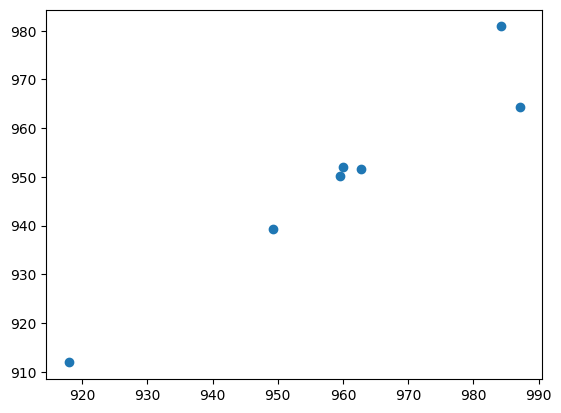

In [25]:
plt.scatter(Y_test,y_pred)

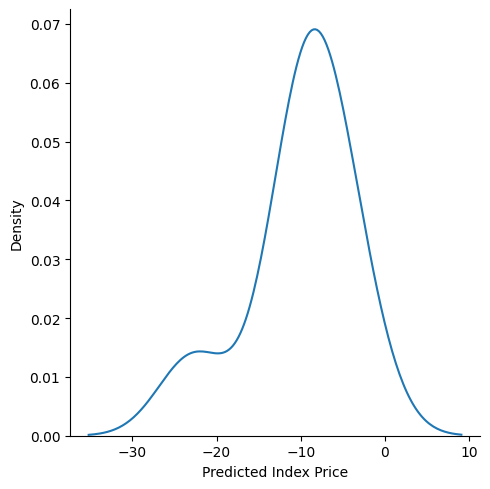

In [28]:
residuals=y_pred-Y_test
sns.displot(residuals,kind='kde')